## Set up

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from stable_baselines3 import A2C, DQN, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

from snake_game import SnakeGameEnv

In [3]:
# -----------------------------
# Reward plotting callback
# -----------------------------
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_reward = 0.0

    def _on_step(self) -> bool:
        reward = self.locals["rewards"][0]
        done = self.locals["dones"][0]

        self.current_reward += reward

        if done:
            self.episode_rewards.append(self.current_reward)
            self.current_reward = 0.0

        return True

def plot_rewards(rewards, window=50):
    """
    Plot rewards with moving average.

    Args:
        rewards: List of reward values per episode
        window: Size of moving average window (default: 50)
    """
    plt.figure(figsize=(10, 5))

    # Convert to numpy array for easier calculations
    rewards_array = np.array(rewards)

    # Calculate moving average
    moving_avg = np.convolve(rewards_array, np.ones(window)/window, mode='valid')

    # Plot original rewards (with transparency)
    plt.plot(rewards, alpha=0.3, label=f"Episode Reward", color='blue', linewidth=0.5)

    # Plot moving average
    # Note: moving_avg starts at episode (window-1) to align properly
    episodes_avg = np.arange(window-1, len(rewards))
    plt.plot(episodes_avg, moving_avg, label=f"{window}-Episode Moving Average",
             color='red', linewidth=2)

    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("A2C Training Rewards (Snake) with Moving Average")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## A2C


=== Training model 1/10 ===
{'learning_rate': 0.0007, 'gamma': 0.99, 'gae_lambda': 1.0, 'ent_coef': 0.01}
Mean reward: 66.40
New best model saved

=== Training model 2/10 ===
{'learning_rate': 0.0005, 'gamma': 0.99, 'gae_lambda': 0.95, 'ent_coef': 0.01}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mean reward: 47.11

=== Training model 3/10 ===
{'learning_rate': 0.001, 'gamma': 0.98, 'gae_lambda': 0.95, 'ent_coef': 0.02}
Mean reward: 74.39
New best model saved

=== Training model 4/10 ===
{'learning_rate': 0.0003, 'gamma': 0.99, 'gae_lambda': 0.9, 'ent_coef': 0.005}
Mean reward: 55.86

=== Training model 5/10 ===
{'learning_rate': 0.0001, 'gamma': 0.97, 'gae_lambda': 0.95, 'ent_coef': 0.01}
Mean reward: 54.87

=== Training model 6/10 ===
{'learning_rate': 0.0007, 'gamma': 0.95, 'gae_lambda': 0.9, 'ent_coef': 0.02}
Mean reward: 72.36

=== Training model 7/10 ===
{'learning_rate': 0.0005, 'gamma': 0.98, 'gae_lambda': 1.0, 'ent_coef': 0.005}
Mean reward: 64.97

=== Training model 8/10 ===
{'learning_rate': 0.0003, 'gamma': 0.99, 'gae_lambda': 0.97, 'ent_coef': 0.01}
Mean reward: 54.33

=== Training model 9/10 ===
{'learning_rate': 0.001, 'gamma': 0.99, 'gae_lambda': 0.9, 'ent_coef': 0.02}
Mean reward: 64.66

=== Training model 10/10 ===
{'learning_rate': 0.0005, 'gamma': 0.97, 'gae

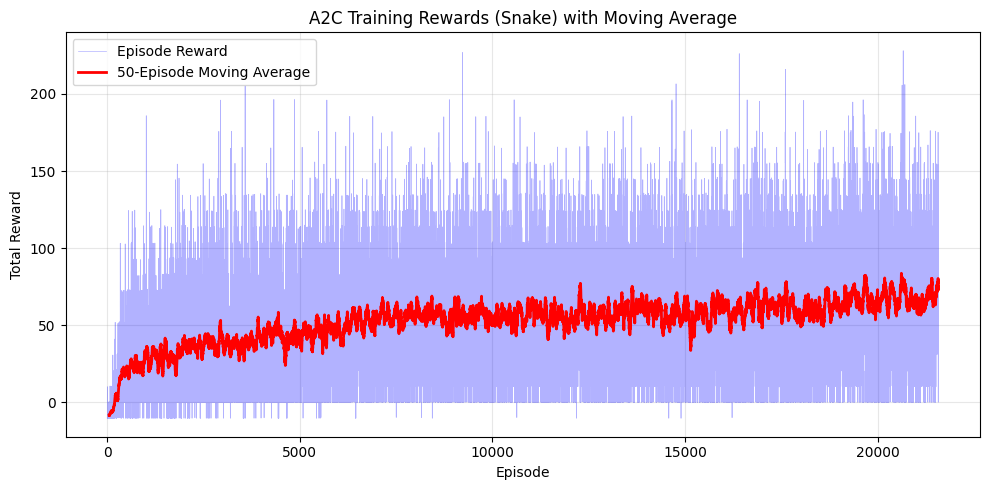

In [ ]:
def train():
    TIMESTEPS = 600_000
    os.makedirs("models", exist_ok=True)

    param_grid = [
        {"learning_rate": 7e-4, "gamma": 0.99, "gae_lambda": 1.0, "ent_coef": 0.01},
        {"learning_rate": 5e-4, "gamma": 0.99, "gae_lambda": 0.95, "ent_coef": 0.01},
        {"learning_rate": 1e-3, "gamma": 0.98, "gae_lambda": 0.95, "ent_coef": 0.02},
        {"learning_rate": 3e-4, "gamma": 0.99, "gae_lambda": 0.9,  "ent_coef": 0.005},
        {"learning_rate": 1e-4, "gamma": 0.97, "gae_lambda": 0.95, "ent_coef": 0.01},
        {"learning_rate": 7e-4, "gamma": 0.95, "gae_lambda": 0.9,  "ent_coef": 0.02},
        {"learning_rate": 5e-4, "gamma": 0.98, "gae_lambda": 1.0,  "ent_coef": 0.005},
        {"learning_rate": 3e-4, "gamma": 0.99, "gae_lambda": 0.97, "ent_coef": 0.01},
        {"learning_rate": 1e-3, "gamma": 0.99, "gae_lambda": 0.9,  "ent_coef": 0.02},
        {"learning_rate": 5e-4, "gamma": 0.97, "gae_lambda": 1.0,  "ent_coef": 0.005},
    ]

    best_score = -np.inf
    best_model = None
    best_model_path = None
    best_rewards = None

    for i, params in enumerate(param_grid):
        print(f"\n=== Training model {i + 1}/{len(param_grid)} ===")
        print(params)

        env = SnakeGameEnv(
            render_mode=None,
            n_channel=1,
            board_size=10,
            n_target=1,
        )
        env = Monitor(env)
        callback = RewardCallback()

        model = A2C(
            policy="MlpPolicy",
            env=env,
            learning_rate=params["learning_rate"],
            n_steps=5,
            gamma=params["gamma"],
            gae_lambda=params["gae_lambda"],
            ent_coef=params["ent_coef"],
            vf_coef=0.5,
            max_grad_norm=0.5,
            verbose=0,
            device="auto",
        )

        model.learn(total_timesteps=TIMESTEPS, callback=callback)

        rewards = np.array(callback.episode_rewards)
        score = rewards[-100:].mean() if len(rewards) >= 100 else rewards.mean()

        print(f"Mean reward: {score:.2f}")

        if score > best_score:
            best_score = score
            best_rewards = rewards
            best_model = model

            best_model_path = f"models/snake_a2c_best"
            model.save(best_model_path)
            print("New best model saved")

        env.close()

    print(f"\nBest model score: {best_score:.2f}")
    print(f"Saved at: {best_model_path}")

    return best_rewards, best_model_path



# -------- Main ---------------------
if __name__ == "__main__":
    rewards, model_path = train()
    plot_rewards(rewards)

    # model_path = "models/snake_a2c_best"
    # watch(model_path)


## DQN


=== Training model 1/10 ===
{'learning_rate': 0.001, 'gamma': 0.99, 'buffer_size': 50000, 'learning_starts': 1000, 'target_update_interval': 500}
Mean reward: 79.55
New best model saved

=== Training model 2/10 ===
{'learning_rate': 0.0005, 'gamma': 0.99, 'buffer_size': 100000, 'learning_starts': 500, 'target_update_interval': 1000}
Mean reward: 75.93

=== Training model 3/10 ===
{'learning_rate': 0.001, 'gamma': 0.98, 'buffer_size': 50000, 'learning_starts': 1000, 'target_update_interval': 250}
Mean reward: 80.70
New best model saved

=== Training model 4/10 ===
{'learning_rate': 0.0003, 'gamma': 0.99, 'buffer_size': 100000, 'learning_starts': 5000, 'target_update_interval': 500}
Mean reward: 65.99

=== Training model 5/10 ===
{'learning_rate': 0.0001, 'gamma': 0.97, 'buffer_size': 10000, 'learning_starts': 100, 'target_update_interval': 100}
Mean reward: 51.03

=== Training model 6/10 ===
{'learning_rate': 0.0007, 'gamma': 0.95, 'buffer_size': 50000, 'learning_starts': 1000, 'target

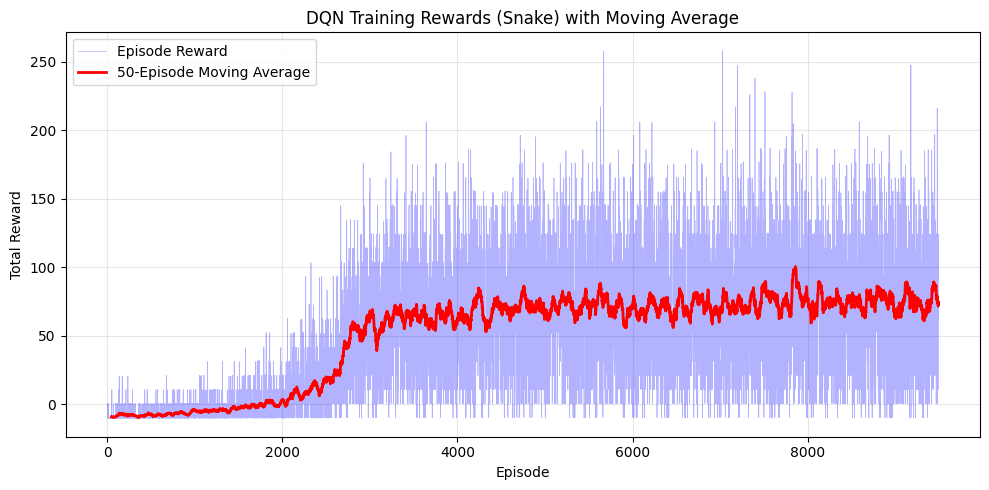

In [ ]:
def train():
    TIMESTEPS = 300_000
    os.makedirs("models", exist_ok=True)

    param_grid = [
        {"learning_rate": 1e-3, "gamma": 0.99, "buffer_size": 50_000, "learning_starts": 1000, "target_update_interval": 500},
        {"learning_rate": 5e-4, "gamma": 0.99, "buffer_size": 100_000, "learning_starts": 500, "target_update_interval": 1000},
        {"learning_rate": 1e-3, "gamma": 0.98, "buffer_size": 50_000, "learning_starts": 1000, "target_update_interval": 250},
        {"learning_rate": 3e-4, "gamma": 0.99, "buffer_size": 100_000, "learning_starts": 5000, "target_update_interval": 500},
        {"learning_rate": 1e-4, "gamma": 0.97, "buffer_size": 10_000, "learning_starts": 100, "target_update_interval": 100},
        {"learning_rate": 7e-4, "gamma": 0.95, "buffer_size": 50_000, "learning_starts": 1000, "target_update_interval": 1000},
        {"learning_rate": 5e-4, "gamma": 0.98, "buffer_size": 100_000, "learning_starts": 10000, "target_update_interval": 500},
        {"learning_rate": 3e-4, "gamma": 0.99, "buffer_size": 50_000, "learning_starts": 5000, "target_update_interval": 250},
        {"learning_rate": 1e-3, "gamma": 0.99, "buffer_size": 10_000, "learning_starts": 100, "target_update_interval": 1000},
        {"learning_rate": 5e-4, "gamma": 0.97, "buffer_size": 100_000, "learning_starts": 5000, "target_update_interval": 100},
    ]

    best_score = -np.inf
    best_model = None
    best_model_path = None
    best_rewards = None

    for i, params in enumerate(param_grid):
        print(f"\n=== Training model {i + 1}/{len(param_grid)} ===")
        print(params)

        env = SnakeGameEnv(
            render_mode=None,
            n_channel=1,
            board_size=6,
            n_target=1,
        )
        env = Monitor(env)
        callback = RewardCallback()

        model = DQN(
            policy="MlpPolicy",
            env=env,
            learning_rate=params["learning_rate"],
            gamma=params["gamma"],
            buffer_size=params["buffer_size"],
            learning_starts=params["learning_starts"],
            target_update_interval=params["target_update_interval"],
            exploration_final_eps=0.05,  
            exploration_fraction=0.1,
            train_freq=4,
            gradient_steps=1,
            verbose=0,
            device="auto",
        )

        model.learn(total_timesteps=TIMESTEPS, callback=callback)

        rewards = np.array(callback.episode_rewards)
        score = rewards[-100:].mean() if len(rewards) >= 100 else rewards.mean()

        print(f"Mean reward: {score:.2f}")

        if score > best_score:
            best_score = score
            best_rewards = rewards
            best_model = model

            best_model_path = f"models/snake_dqn_best"
            model.save(best_model_path)
            print("New best model saved")

        env.close()

    print(f"\nBest model score: {best_score:.2f}")
    print(f"Saved at: {best_model_path}")

    return best_rewards, best_model_path


def plot_rewards(rewards, window=50):
    plt.figure(figsize=(10, 5))
    rewards_array = np.array(rewards)
    moving_avg = np.convolve(rewards_array, np.ones(window)/window, mode='valid')
    plt.plot(rewards, alpha=0.3, label=f"Episode Reward", color='blue', linewidth=0.5)
    episodes_avg = np.arange(window-1, len(rewards))
    plt.plot(episodes_avg, moving_avg, label=f"{window}-Episode Moving Average",
             color='red', linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("DQN Training Rewards (Snake) with Moving Average")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# -------- Main ---------------------
if __name__ == "__main__":
    rewards, model_path = train()
    plot_rewards(rewards)


## PPO


=== Training model 1/10 ===
{'learning_rate': 0.0003, 'gamma': 0.99, 'gae_lambda': 0.95, 'clip_range': 0.2, 'ent_coef': 0.01}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mean reward: 78.60
New best model saved

=== Training model 2/10 ===
{'learning_rate': 0.001, 'gamma': 0.99, 'gae_lambda': 0.9, 'clip_range': 0.1, 'ent_coef': 0.02}
Mean reward: 94.75
New best model saved

=== Training model 3/10 ===
{'learning_rate': 0.00025, 'gamma': 0.98, 'gae_lambda': 0.95, 'clip_range': 0.2, 'ent_coef': 0.005}
Mean reward: 103.92
New best model saved

=== Training model 4/10 ===
{'learning_rate': 0.0005, 'gamma': 0.99, 'gae_lambda': 0.97, 'clip_range': 0.3, 'ent_coef': 0.001}
Mean reward: 106.20
New best model saved

=== Training model 5/10 ===
{'learning_rate': 0.0001, 'gamma': 0.97, 'gae_lambda': 0.9, 'clip_range': 0.2, 'ent_coef': 0.02}
Mean reward: 66.23

=== Training model 6/10 ===
{'learning_rate': 0.0003, 'gamma': 0.95, 'gae_lambda': 0.95, 'clip_range': 0.1, 'ent_coef': 0.01}
Mean reward: 85.66

=== Training model 7/10 ===
{'learning_rate': 0.0007, 'gamma': 0.99, 'gae_lambda': 0.9, 'clip_range': 0.3, 'ent_coef': 0.005}
Mean reward: 104.84

=== Training mode

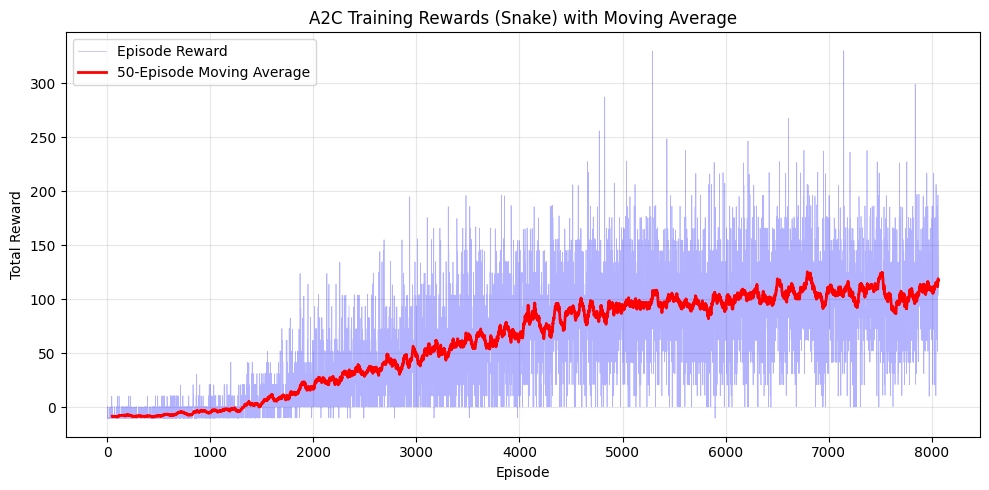

In [ ]:
def train():
    TIMESTEPS = 300_000
    os.makedirs("models", exist_ok=True)

    param_grid = [
        {"learning_rate": 3e-4, "gamma": 0.99, "gae_lambda": 0.95, "clip_range": 0.2, "ent_coef": 0.01},
        {"learning_rate": 1e-3, "gamma": 0.99, "gae_lambda": 0.9, "clip_range": 0.1, "ent_coef": 0.02},
        {"learning_rate": 2.5e-4, "gamma": 0.98, "gae_lambda": 0.95, "clip_range": 0.2, "ent_coef": 0.005},
        {"learning_rate": 5e-4, "gamma": 0.99, "gae_lambda": 0.97, "clip_range": 0.3, "ent_coef": 0.001},
        {"learning_rate": 1e-4, "gamma": 0.97, "gae_lambda": 0.9, "clip_range": 0.2, "ent_coef": 0.02},
        {"learning_rate": 3e-4, "gamma": 0.95, "gae_lambda": 0.95, "clip_range": 0.1, "ent_coef": 0.01},
        {"learning_rate": 7e-4, "gamma": 0.99, "gae_lambda": 0.9, "clip_range": 0.3, "ent_coef": 0.005},
        {"learning_rate": 1e-3, "gamma": 0.98, "gae_lambda": 0.95, "clip_range": 0.2, "ent_coef": 0.001},
        {"learning_rate": 5e-4, "gamma": 0.99, "gae_lambda": 0.8, "clip_range": 0.2, "ent_coef": 0.02},
        {"learning_rate": 2.5e-4, "gamma": 0.96, "gae_lambda": 0.99, "clip_range": 0.1, "ent_coef": 0.01},
    ]

    best_score = -np.inf
    best_model = None
    best_model_path = None
    best_rewards = None

    for i, params in enumerate(param_grid):
        print(f"\n=== Training model {i + 1}/{len(param_grid)} ===")
        print(params)

        env = SnakeGameEnv(
            render_mode=None,
            n_channel=1,
            board_size=6,
            n_target=1,
        )
        env = Monitor(env)
        callback = RewardCallback()

        model = PPO(
            policy="MlpPolicy",
            env=env,
            learning_rate=params["learning_rate"],
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=params["gamma"],
            gae_lambda=params["gae_lambda"],
            clip_range=params["clip_range"],
            ent_coef=params["ent_coef"],
            vf_coef=0.5,
            max_grad_norm=0.5,
            verbose=0,
            device="auto",
        )

        model.learn(total_timesteps=TIMESTEPS, callback=callback)

        rewards = np.array(callback.episode_rewards)
        score = rewards[-100:].mean() if len(rewards) >= 100 else rewards.mean()

        print(f"Mean reward: {score:.2f}")

        if score > best_score:
            best_score = score
            best_rewards = rewards
            best_model = model

            best_model_path = f"models/snake_ppo_best"
            model.save(best_model_path)
            print("New best model saved")

        env.close()

    print(f"\nBest model score: {best_score:.2f}")
    print(f"Saved at: {best_model_path}")

    return best_rewards, best_model_path

def plot_rewards(rewards, window=50):
    """
    Plot rewards with moving average.

    Args:
        rewards: List of reward values per episode
        window: Size of moving average window (default: 50)
    """
    plt.figure(figsize=(10, 5))
    rewards_array = np.array(rewards)

    moving_avg = np.convolve(rewards_array, np.ones(window)/window, mode='valid')

    plt.plot(rewards, alpha=0.3, label=f"Episode Reward", color='blue', linewidth=0.5)

    episodes_avg = np.arange(window-1, len(rewards))
    plt.plot(episodes_avg, moving_avg, label=f"{window}-Episode Moving Average",
             color='red', linewidth=2)

    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("PPO Training Rewards (Snake) with Moving Average")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



# -------- Main ---------------------
if __name__ == "__main__":
    # rewards, model_path = train()
    plot_rewards(rewards)

    # model_path = "models/snake_ppo_best"
    # watch(model_path)